In [4]:
pip install pandas numpy matplotlib scikit-learn


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
# ============================================================
# ARTI 406 - Assignment 2
# Heart Disease Dataset
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('heart.csv')

print("=" * 60)
print("ASSIGNMENT 2 - HEART DISEASE DATASET")
print("=" * 60)
print(f"\nDataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

ASSIGNMENT 2 - HEART DISEASE DATASET

Dataset shape: (1025, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [6]:
# ============================================================
# TASK 1: Identify Data Quality Issues
# ============================================================
print("\n" + "=" * 60)
print("TASK 1: DATA QUALITY ISSUES")
print("=" * 60)

print("\n1. Missing Values:")
print(df.isnull().sum())
print(f"   Total missing: {df.isnull().sum().sum()}")

print(f"\n2. Duplicate Rows: {df.duplicated().sum()}")
print(f"   ({df.duplicated().sum()} out of {len(df)} rows = "
      f"{df.duplicated().sum()/len(df)*100:.1f}%)")

print("\n3. Data Types:")
print(df.dtypes)

print("\n4. Statistical Summary:")
print(df.describe())

print("\n5. Suspicious Values:")
print(f"   thal = 0: {(df['thal'] == 0).sum()} rows "
      f"(0 is not a valid thalassemia category)")
print(f"   ca = 4:   {(df['ca'] == 4).sum()} rows "
      f"(expected range is 0-3)")

print("\nSUMMARY OF DATA QUALITY ISSUES FOUND:")
print("  - No missing values detected")
print(f"  - 723 duplicate rows (70.5% of dataset)")
print("  - thal column has 7 rows with value 0 (invalid category)")
print("  - ca column has 18 rows with value 4 (out of expected range)")


TASK 1: DATA QUALITY ISSUES

1. Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
   Total missing: 0

2. Duplicate Rows: 723
   (723 out of 1025 rows = 70.5%)

3. Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

4. Statistical Summary:
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0

In [7]:
# ============================================================
# TASK 2: Missing Value Strategy
# ============================================================
print("\n" + "=" * 60)
print("TASK 2: MISSING VALUE STRATEGY")
print("=" * 60)

# Step 1: Remove duplicates
print("\nStep 1 - Remove duplicate rows:")
df = df.drop_duplicates()
print(f"  Dataset shape after removing duplicates: {df.shape}")

# Step 2: Fix invalid values in thal and ca
print("\nStep 2 - Fix invalid values (replace with NaN):")
df['thal'] = df['thal'].replace(0, np.nan)
df['ca']   = df['ca'].replace(4, np.nan)
print(f"  thal missing after fix: {df['thal'].isnull().sum()}")
print(f"  ca missing after fix:   {df['ca'].isnull().sum()}")

# Step 3: Apply MEDIAN strategy
print("\nStep 3 - Fill missing values using MEDIAN:")
for col in ['thal', 'ca']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"  {col}: filled with median = {median_val}")

print("\nAfter handling:")
print(df[['thal', 'ca']].isnull().sum())

print("\nWHY MEDIAN?")
print("  - thal and ca are categorical/ordinal columns")
print("  - Median preserves valid category values (no fractional results)")
print("  - Median is robust to outliers unlike mean")
print("  - Suitable when distribution may be skewed")


TASK 2: MISSING VALUE STRATEGY

Step 1 - Remove duplicate rows:
  Dataset shape after removing duplicates: (302, 14)

Step 2 - Fix invalid values (replace with NaN):
  thal missing after fix: 2
  ca missing after fix:   4

Step 3 - Fill missing values using MEDIAN:
  thal: filled with median = 2.0
  ca: filled with median = 0.0

After handling:
thal    0
ca      0
dtype: int64

WHY MEDIAN?
  - thal and ca are categorical/ordinal columns
  - Median preserves valid category values (no fractional results)
  - Median is robust to outliers unlike mean
  - Suitable when distribution may be skewed


In [8]:
# ============================================================
# TASK 3: Detect and Handle Outliers using IQR
# ============================================================
print("\n" + "=" * 60)
print("TASK 3: OUTLIER DETECTION USING IQR")
print("=" * 60)

num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for col in num_cols:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers_before = len(df[(df[col] < lower) | (df[col] > upper)])

    # Cap outliers (Winsorization)
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

    outliers_after = len(df[(df[col] < lower) | (df[col] > upper)])

    print(f"\n{col}:")
    print(f"  Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"  Lower bound={lower:.2f}, Upper bound={upper:.2f}")
    print(f"  Outliers before capping: {outliers_before}")
    print(f"  Outliers after capping:  {outliers_after}")

print("\nOUTLIER HANDLING METHOD: Capping (Winsorization)")
print("  - Values below lower bound are set to lower bound")
print("  - Values above upper bound are set to upper bound")
print("  - No data is removed, which preserves dataset size")


TASK 3: OUTLIER DETECTION USING IQR

age:
  Q1=48.00, Q3=61.00, IQR=13.00
  Lower bound=28.50, Upper bound=80.50
  Outliers before capping: 0
  Outliers after capping:  0

trestbps:
  Q1=120.00, Q3=140.00, IQR=20.00
  Lower bound=90.00, Upper bound=170.00
  Outliers before capping: 9
  Outliers after capping:  0

chol:
  Q1=211.00, Q3=274.75, IQR=63.75
  Lower bound=115.38, Upper bound=370.38
  Outliers before capping: 5
  Outliers after capping:  0

thalach:
  Q1=133.25, Q3=166.00, IQR=32.75
  Lower bound=84.12, Upper bound=215.12
  Outliers before capping: 1
  Outliers after capping:  0

oldpeak:
  Q1=0.00, Q3=1.60, IQR=1.60
  Lower bound=-2.40, Upper bound=4.00
  Outliers before capping: 5
  Outliers after capping:  0

OUTLIER HANDLING METHOD: Capping (Winsorization)
  - Values below lower bound are set to lower bound
  - Values above upper bound are set to upper bound
  - No data is removed, which preserves dataset size


In [9]:
# ============================================================
# TASK 4: Normalization (Min-Max and Z-score)
# ============================================================
print("\n" + "=" * 60)
print("TASK 4: NORMALIZATION")
print("=" * 60)

features_to_norm = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

print("\nOriginal data (first 5 rows):")
print(df[features_to_norm].head())

# Min-Max
scaler_minmax = MinMaxScaler()
df_minmax     = df.copy()
df_minmax[features_to_norm] = scaler_minmax.fit_transform(df[features_to_norm])

print("\n" + "-" * 40)
print("MIN-MAX NORMALIZATION (range: 0 to 1)")
print("Formula: (x - min) / (max - min)")
print("-" * 40)
print(df_minmax[features_to_norm].head())
print("\nMin-Max stats (should be 0 to 1):")
print(df_minmax[features_to_norm].describe().loc[['min', 'max']])

# Z-score
scaler_zscore = StandardScaler()
df_zscore     = df.copy()
df_zscore[features_to_norm] = scaler_zscore.fit_transform(df[features_to_norm])

print("\n" + "-" * 40)
print("Z-SCORE NORMALIZATION (mean=0, std=1)")
print("Formula: (x - mean) / std")
print("-" * 40)
print(df_zscore[features_to_norm].head())
print("\nZ-score stats (mean ≈ 0, std ≈ 1):")
print(df_zscore[features_to_norm].describe().loc[['mean', 'std']])

print("\nWHEN TO USE EACH:")
print("  Min-Max → when algorithm needs values in fixed range (e.g. neural networks)")
print("  Z-score → when algorithm assumes normal distribution (e.g. PCA, SVM)")


TASK 4: NORMALIZATION

Original data (first 5 rows):
    age  trestbps   chol  thalach  oldpeak
0  52.0     125.0  212.0    168.0      1.0
1  53.0     140.0  203.0    155.0      3.1
2  70.0     145.0  174.0    125.0      2.6
3  61.0     148.0  203.0    161.0      0.0
4  62.0     138.0  294.0    106.0      1.9

----------------------------------------
MIN-MAX NORMALIZATION (range: 0 to 1)
Formula: (x - min) / (max - min)
----------------------------------------
        age  trestbps      chol   thalach  oldpeak
0  0.479167  0.407895  0.351918  0.711559    0.250
1  0.500000  0.605263  0.315090  0.601273    0.775
2  0.854167  0.671053  0.196419  0.346766    0.650
3  0.666667  0.710526  0.315090  0.652174    0.000
4  0.687500  0.578947  0.687468  0.185578    0.475

Min-Max stats (should be 0 to 1):
     age  trestbps  chol  thalach  oldpeak
min  0.0       0.0   0.0      0.0      0.0
max  1.0       1.0   1.0      1.0      1.0

----------------------------------------
Z-SCORE NORMALIZATION 


TASK 5: PCA AND EXPLAINED VARIANCE
Input shape: (302, 5)
Features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

----------------------------------------
EXPLAINED VARIANCE PER COMPONENT
----------------------------------------
  PC1: 36.19%  |  Cumulative: 36.19%
  PC2: 21.65%  |  Cumulative: 57.84%
  PC3: 17.25%  |  Cumulative: 75.09%
  PC4: 15.29%  |  Cumulative: 90.39%
  PC5: 9.61%  |  Cumulative: 100.00%


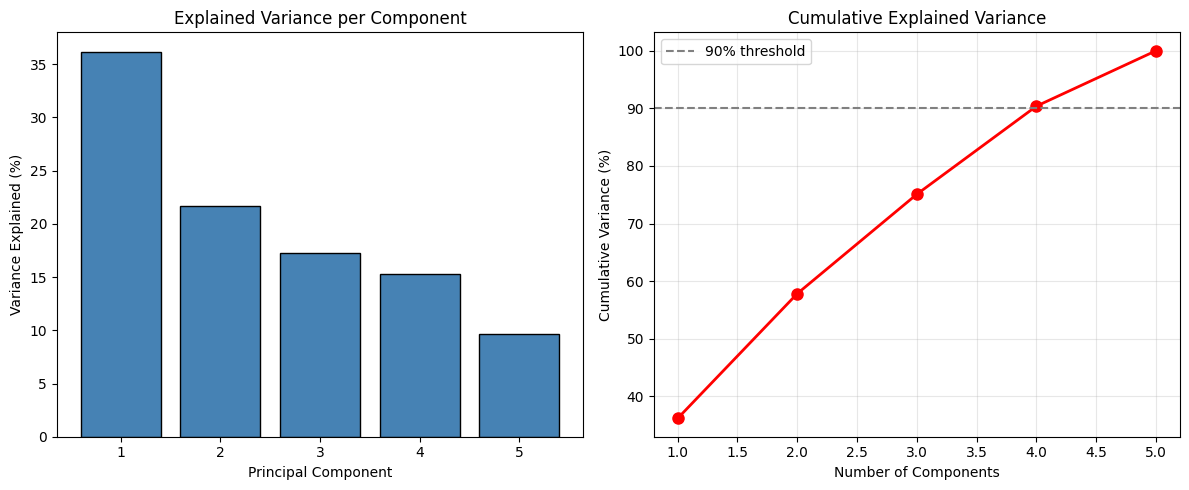


----------------------------------------
INTERPRETATION
----------------------------------------
  PC1 alone explains 36.19% of variance
  PC1 + PC2 explain 57.84% of variance
  PC1 + PC2 + PC3 explain 75.09% of variance

  Conclusion:
  We can reduce from 5 features to 3 principal components
  while retaining 75.1% of the original information.
  This reduces dimensionality by 40% with minimal information loss.


In [10]:
# ============================================================
# TASK 5: PCA and Explained Variance
# ============================================================
print("\n" + "=" * 60)
print("TASK 5: PCA AND EXPLAINED VARIANCE")
print("=" * 60)

# Use Z-score normalized data for PCA (best practice)
X = df_zscore[features_to_norm]
print(f"Input shape: {X.shape}")
print(f"Features: {features_to_norm}")

pca        = PCA()
pca_result = pca.fit_transform(X)

explained_var  = pca.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

print("\n" + "-" * 40)
print("EXPLAINED VARIANCE PER COMPONENT")
print("-" * 40)
for i, (var, cum) in enumerate(zip(explained_var, cumulative_var)):
    print(f"  PC{i+1}: {var*100:.2f}%  |  Cumulative: {cum*100:.2f}%")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(range(1, len(explained_var) + 1),
            explained_var * 100, color='steelblue', edgecolor='black')
axes[0].set_title('Explained Variance per Component')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_xticks(range(1, len(explained_var) + 1))

axes[1].plot(range(1, len(cumulative_var) + 1),
             cumulative_var * 100, 'ro-', linewidth=2, markersize=8)
axes[1].axhline(y=90, color='gray', linestyle='--', label='90% threshold')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150)
plt.show()

print("\n" + "-" * 40)
print("INTERPRETATION")
print("-" * 40)
print(f"  PC1 alone explains {explained_var[0]*100:.2f}% of variance")
print(f"  PC1 + PC2 explain {cumulative_var[1]*100:.2f}% of variance")
print(f"  PC1 + PC2 + PC3 explain {cumulative_var[2]*100:.2f}% of variance")
print(f"\n  Conclusion:")
print(f"  We can reduce from 5 features to 3 principal components")
print(f"  while retaining {cumulative_var[2]*100:.1f}% of the original information.")
print(f"  This reduces dimensionality by 40% with minimal information loss.")